In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import tensorflow as tf
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

import h5py, time
from tqdm import tqdm

from deepsphere import healpy_layers

from msfm.fiducial_pipeline import FiducialPipeline
from deep_lss.models.delta_model import DeltaLossModel
from deep_lss.nets.resnet import ResNetLayers

23-10-26 08:50:54   imports.py INF   Setting up healpy to run on 256 CPUs 
23-10-26 08:50:54   imports.py INF   Setting up healpy to run on 256 CPUs 


In [3]:
tfr_pattern = "/pscratch/sd/a/athomsen/DESY3/v5/linear_bias/tfrecords/fiducial/DESy3_fiducial_???.tfrecord"
conf = "/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v5/linear_bias.yaml"
params = ["Om", "s8", "Aia", "n_Aia", "bg", "n_bg"]

In [4]:
fidu_pipe = FiducialPipeline(
    conf=conf,
    params=params,
    with_lensing=True,
    with_clustering=True,
    with_padding=True,
    apply_norm=False,
    shape_noise_scale=1.0,
    poisson_noise_scale=1.0,    
)

n_side = 512
n_pix = hp.nside2npix(n_side)

params = fidu_pipe.params
n_params = len(params)
n_maps = 2 * len(params) + 1 
n_noise = 3
data_vec_pix = fidu_pipe.data_vec_pix
n_z = fidu_pipe.n_z_metacal + fidu_pipe.n_z_maglim
n_z_metacal = fidu_pipe.n_z_metacal

n_neighbors = 20

23-10-26 08:50:55     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 
23-10-26 08:50:55     files.py INF   Loaded the pixel file /global/u2/a/athomsen/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 


In [5]:
batch_size = 4

dset = fidu_pipe.get_dset(
    tfr_pattern=tfr_pattern,
    local_batch_size=batch_size,
    n_noise=n_noise,
    n_readers=1,
    examples_shuffle_buffer=None,
    n_prefetch=0,
    is_eval=True,
)

23-10-26 08:50:58 fiducial_pip WAR   Evaluation mode is activated: the random seed is fixed, the shuffle arguments ignored, and the dataset is not repeated 
23-10-26 08:50:58 fiducial_pip INF   Interleaving with n_readers = 1 


/global/common/software/des/athomsen/dlss/lib/python3.9/site-packages/tensorflow/python/data/ops/dataset_ops.py:2210: UserWarning: The `deterministic` argument has no effect unless the `num_parallel_calls` argument is specified.
  warnings.warn("The `deterministic` argument has no effect unless the "


23-10-26 08:50:58 fiducial_pip INF   Batching into 4 elements locally 
23-10-26 08:50:59 fiducial_pip WAR   Tracing _augmentations 
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module, class, method, function, traceback, frame, or code object was expected, got cython_function_or_method
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module, class, method, function, traceback, frame, or code object was expected, got cython_function_or_method
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
23-10-26 08:51:00 fiducial_pip INF   Running on the data_vectors.keys() = dict_keys(['kg_fiducial', 'dg_fiducial', 'kg_delta_O

In [6]:
for data_vector, index in dset.take(1):
    pass

print(data_vector.shape)
print(index)

(52, 464896, 8)
(<tf.Tensor: shape=(4,), dtype=int64, numpy=array([591, 591, 591, 341])>, <tf.Tensor: shape=(4,), dtype=int32, numpy=array([0, 1, 2, 0], dtype=int32)>)


In [7]:
# vanilla network configuration
network = ResNetLayers(
    output_shape=n_params,
    n_base_channels=32,
    # depth
    n_downsampling=3,
    n_cheby=2,
    n_residuals=5,
    # misc
    poly_degree=5,   
).get_layers()

In [8]:
# build the model
vanilla_model = DeltaLossModel(
    network=network,
    n_side=n_side,
    indices=data_vec_pix,
    n_neighbors=n_neighbors,
    input_shape=(None, data_vector.shape[1], data_vector.shape[2]),
    max_batch_size=data_vector.shape[0],
    checkpoint_dir=None,
    summary_dir=None,
    restore_checkpoint=False,
)

23-10-25 08:09:20 delta_model. INF   Initializing DeltaLossModel with a HealpyGCNN model 
Detected a reduction factor of 32.0, the input with nside 512 will be transformed to 16 during a forward pass. Checking for consistency with indices...
indices seem consistent...
Tracing... Due to tensor size, tf.sparse.sparse_dense_matmul is executed over 4 splits. Beware of the resulting performance penalty.
Tracing... Due to tensor size, tf.sparse.sparse_dense_matmul is executed over 4 splits. Beware of the resulting performance penalty.
Model: "healpy_gcnn_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 healpy_pseudo_conv (HealpyP  (None, 116224, 32)       1056      
 seudoConv)                                                      
                                                                 
 healpy_pseudo_conv_1 (Healp  (None, 29056, 64)        8256      
 yPseudoConv)                                 

# one batch of the fiducial network

(416, 464896, 8)


100%|██████████| 415/415 [07:46<00:00,  1.12s/it]


[Text(0.5, 0, 'batch size'), Text(0, 0.5, 't in s')]

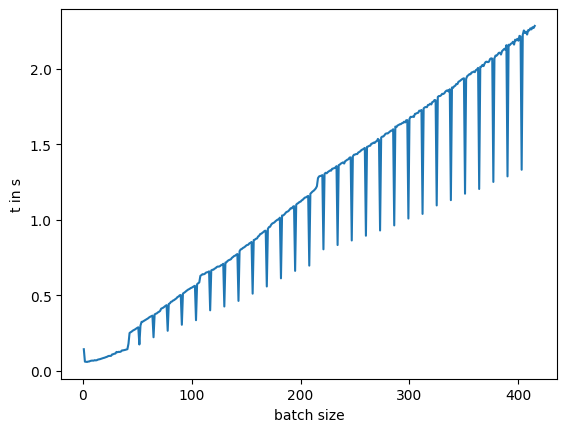

In [50]:
# trace the network
vanilla_model(data_vector[:0])

print(data_vector.shape)
delta_batch_factor = 2 * n_params + 1

delta_t = []
batch_sizes = []
t0 = time.time()
for i in tqdm(range(1, data_vector.shape[0])):    
    vanilla_model(data_vector[:i])
    t1 = time.time()
    
    delta_t.append(t1 - t0)
    batch_sizes.append(i)
    t0 = t1
    
fig, ax = plt.subplots()
ax.plot(batch_sizes, delta_t)
ax.set(xlabel="batch size", ylabel="t in s") 

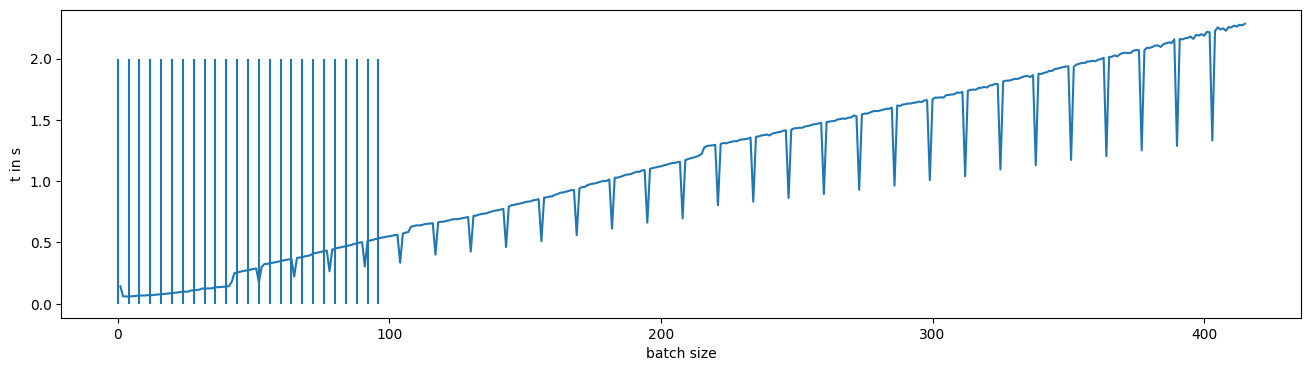

In [60]:
fig, ax = plt.subplots(figsize=(16,4))
ax.plot(batch_sizes, delta_t)
ax.set(xlabel="batch size", ylabel="t in s")

ax.vlines([4*i for i in range(25)], 0, 2)

In [9]:
temp = vanilla_model(data_vector)

2023-10-25 08:09:27.503462: W tensorflow/core/kernels/gpu_utils.cc:50] Failed to allocate memory for convolution redzone checking; skipping this check. This is benign and only means that we won't check cudnn for out-of-bounds reads and writes. This message will only be printed once.


In [10]:
print(data_vector.shape)
print(temp.shape)

(416, 464896, 8)
(416, 6)


In [14]:
%%timeit
vanilla_model(data_vector)

75 ms ± 4.95 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


# one batch of a single full resolution Chebyshev layer

In [7]:
cheby_model = DeltaLossModel(
    network=[healpy_layers.HealpyChebyshev(K=10, Fout=8, activation=tf.nn.relu)],
    n_side=n_side,
    indices=data_vec_pix,
    n_neighbors=60,
    input_shape=(None, data_vector.shape[1], data_vector.shape[2]),
    initial_Fin=data_vector.shape[2],
    max_batch_size=data_vector.shape[0],
    checkpoint_dir=None,
    summary_dir=None,
    restore_checkpoint=False,
)
cheby_model(data_vector);

23-10-26 08:51:54 delta_model. INF   Initializing DeltaLossModel with a HealpyGCNN model 
Detected a reduction factor of 1.0, the input with nside 512 will be transformed to 512 during a forward pass. Checking for consistency with indices...
indices seem consistent...
Tracing... Due to tensor size, tf.sparse.sparse_dense_matmul is executed over 8 splits. Beware of the resulting performance penalty.
Model: "healpy_gcnn_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 chebyshev (Chebyshev)       (None, 464896, 8)         640       
                                                                 
Total params: 640
Trainable params: 640
Non-trainable params: 0
_________________________________________________________________
23-10-26 08:52:09 base_model.p INF   The network is initialized from scratch. 
23-10-26 08:52:09 delta_model. INF   Initialized the DeltaLossModel 


In [8]:
%%timeit
cheby_model(data_vector)

1.25 s ± 266 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
# Fout = 8 -> 556
# Fout = 1 -> 554
# Fout = 64 -> 567
# Fout = 128 -> 567

In [15]:
temp = cheby_model(data_vector)
print(data_vector.shape)
print(temp.shape)

(52, 464896, 8)
(52, 464896, 8)
